In [1]:
!pip install scikit-learn

In [4]:
#import the libarries
import numpy as np
import pandas as pd
import sklearn

In [5]:
data = pd.DataFrame({'Price_USE':[80,50,140,25],'Price_INR':[5000,7000,12000,3000]})
data

,Price_USE,Price_INR
0,80,5000
1,50,7000
2,140,12000
3,25,3000


In [6]:
data['Price_USA_minmax'] = (data['Price_USA'] - data['Price_USA'].min())/(data['Price_USA'].max() - data['Price_USA'].min())
data

KeyError: 'Price_USA'

In [7]:
data['Price_INR_minmax'] = (data['Price_INR'] - data['Price_INR'].min())/(data['Price_INR'].max() - data['Price_INR'].min())
data

,Price_USE,Price_INR,Price_INR_minmax
0,80,5000,0.222222
1,50,7000,0.444444
2,140,12000,1.000000
3,25,3000,0.000000


In [10]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [11]:
min_max = MinMaxScaler()

In [12]:
data['Price_USA_minsk'] = min_max.fit_transform(data[['Price_USA']])
data

KeyError: "None of [Index(['Price_USA'], dtype='object')] are in the [columns]"

In [13]:
!pip install ucimlrepo


In [1]:
 import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import OneHotEncoder,PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
sns.set_style(style='whitegrid')#background style of graphs

In [2]:
data = fetch_ucirepo(id=9)
data
X=data.data.features.copy()  #returns all numericals
X

,displacement,cylinders,horsepower,weight,acceleration,model_year,origin
0,307.0,8,130.0,3504,12.0,70,1
1,350.0,8,165.0,3693,11.5,70,1
2,318.0,8,150.0,3436,11.0,70,1
3,304.0,8,150.0,3433,12.0,70,1
4,302.0,8,140.0,3449,10.5,70,1
...,...,...,...,...,...,...,...
393,140.0,4,86.0,2790,15.6,82,1
394,97.0,4,52.0,2130,24.6,82,2
395,135.0,4,84.0,2295,11.6,82,1
396,120.0,4,79.0,2625,18.6,82,1


In [9]:
y= data.data.targets['mpg']

In [10]:
X.describe()

,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


In [11]:
X['origin'].unique();
X['horsepower'].unique()

array([130., 165., 150., 140., 198., 220., 215., 225., 190., 170., 160.,
        95.,  97.,  85.,  88.,  46.,  87.,  90., 113., 200., 210., 193.,
        nan, 100., 105., 175., 153., 180., 110.,  72.,  86.,  70.,  76.,
        65.,  69.,  60.,  80.,  54., 208., 155., 112.,  92., 145., 137.,
       158., 167.,  94., 107., 230.,  49.,  75.,  91., 122.,  67.,  83.,
        78.,  52.,  61.,  93., 148., 129.,  96.,  71.,  98., 115.,  53.,
        81.,  79., 120., 152., 102., 108.,  68.,  58., 149.,  89.,  63.,
        48.,  66., 139., 103., 125., 133., 138., 135., 142.,  77.,  62.,
       132.,  84.,  64.,  74., 116.,  82.])

In [12]:
X['horsepower'] = pd.to_numeric(X['horsepower'], errors='coerce')
#X['horsepower'].info()
X['origin'] = X['origin'].astype(str)

In [13]:
numerical_features = ['cylinders','displacement', 'horsepower', 'weight', 'acceleration', 'model_year']
categorical_features=['origin']
X = X[numerical_features +categorical_features]
X.info()
X.isnull().sum()  #gives missing values in each col
X.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   cylinders     398 non-null    int64  
 1   displacement  398 non-null    float64
 2   horsepower    392 non-null    float64
 3   weight        398 non-null    int64  
 4   acceleration  398 non-null    float64
 5   model_year    398 non-null    int64  
 6   origin        398 non-null    object 
dtypes: float64(3), int64(3), object(1)
memory usage: 21.9+ KB


(398, 7)

In [14]:
df = X.copy()
df['mpg'] = y

<Axes: xlabel='mpg', ylabel='Count'>

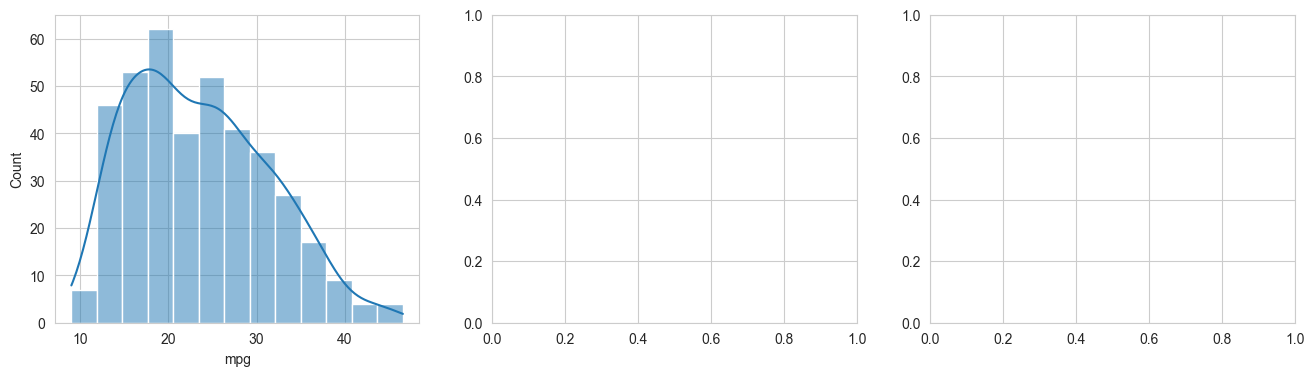

In [16]:
#we gonna use sunplots() concept to divide the plot into multiple plots
fig,axes = plt.subplots(1,3,figsize=(16,4))
#plot graphs as per axis
sns.histplot(df['mpg'],kde=True, ax=axes[0])

Text(0.5, 1.0, 'Horsepower vs MPG Distribution')

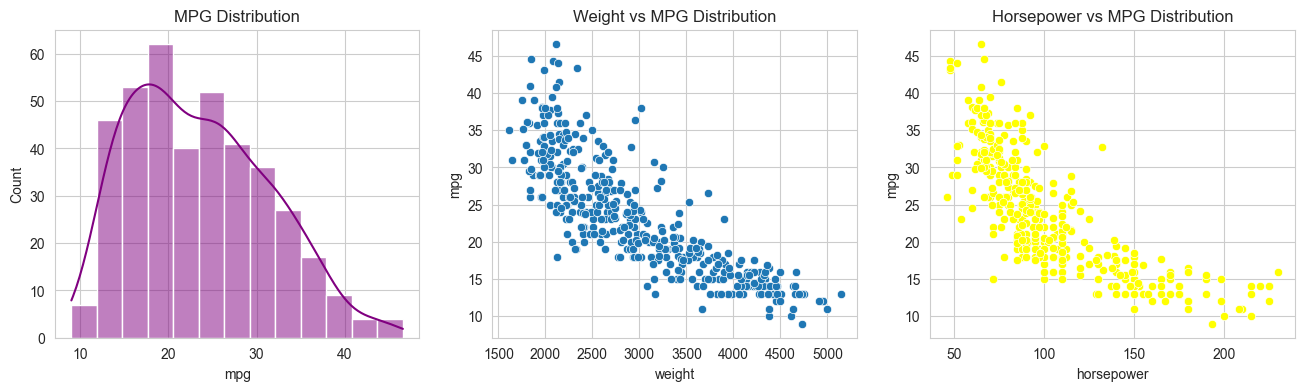

In [18]:
fig,axes = plt.subplots(1,3,figsize=(16,4))
#plot graphs as per axis
sns.histplot(df['mpg'],kde=True, ax=axes[0], color='purple')
#similar way we display other graphs
axes[0].set_title("MPG Distribution")
sns.scatterplot(x=df['weight'], y=df['mpg'], ax=axes[1])
axes[1].set_title("Weight vs MPG Distribution")
sns.scatterplot(x=df['horsepower'], y=df['mpg'], ax=axes[2], color='yellow')
axes[2].set_title("Horsepower vs MPG Distribution")                                                                                                  

<Axes: >

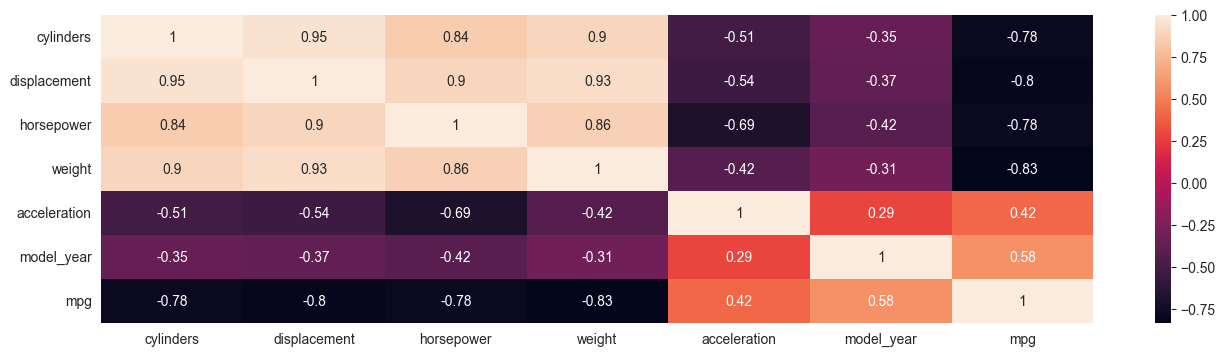

In [19]:
#Corelation b/w our variables
plt.figure(figsize=(16,4))
sns.heatmap(df.select_dtypes(include=np.number).corr(),annot=True)

In [20]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=42)
print('\n Train test Split')
print("Training Data", len(X_train))
print("Testing Data", len(X_test))
print(X_train)


 Train test Split
Training Data 318
Testing Data 80
     cylinders  displacement  horsepower  weight  acceleration  model_year  \
3            8         304.0       150.0    3433          12.0          70   
18           4          97.0        88.0    2130          14.5          70   
376          4          91.0        68.0    2025          18.2          82   
248          4          91.0        60.0    1800          16.4          78   
177          4         115.0        95.0    2694          15.0          75   
..         ...           ...         ...     ...           ...         ...   
71           3          70.0        97.0    2330          13.5          72   
106          8         350.0       180.0    4499          12.5          73   
270          4         134.0        95.0    2515          14.8          78   
348          4          89.0        62.0    2050          17.3          81   
102          4          97.0        46.0    1950          21.0          73   

    origin

In [21]:
def evaluate(model_name,actual,predicted):
    """Returns MAE,MSE,RMSE,R2-Score"""
    mse = mean_squared_error(actual,predicted)
    return {'Model_Name': model_name,
    'MAE':mean_absolute_error,
    'MSE': mse,
    'RMSE': np.sqrt(mse),
    'R2-Score': r2_score(actual,predicted )}
results = []

In [22]:
baseline_predictions = np.full(len(y_test),y_train.mean())
#baseline_predictions
#in above case we are keeping baseline prediction
results.append(evaluate("Mean baseline", y_test, baseline_predictions))
results

[{'Model_Name': 'Mean baseline',
  'MAE': <function sklearn.metrics._regression.mean_absolute_error(y_true, y_pred, *, sample_weight=None, multioutput='uniform_average')>,
  'MSE': 53.98329798069697,
  'RMSE': np.float64(7.347332711991268),
  'R2-Score': -0.00403326341807686}]